# Pipeline Stage-by-Stage Debugger

A debugging notebook where **each pipeline sub-step gets its own cell** so
we can inspect each intermediate step in isolation — before moving to the next cell. This helps us understand how the method works, how different steps in the process impact the results, and diagnose and resolve any issues.

Every cell calls `inspect()`, which:
1. Runs the same three formal QA checks (`all_nan`, `out_of_range`,
   `sporadic_nan_days`) from `saidownscale.qa_checks` — the same checks a
   `bcsd qa` run applies to a cached artifact.
2. Prints a PASS/FAIL verdict per check.
3. Plots a spatial map (`time=0`) and a domain-mean time series.
4. Registers the computed array in the `STEPS` dict so the cross-stage
   evolution plots at the bottom can iterate over every step.



In [1]:
%load_ext autoreload
%autoreload 2

import textwrap
import warnings

import icechunk
import matplotlib.pyplot as plt
import numpy as np
import rasterix  # noqa: F401  # registers .proj/.rio accessors
import xarray as xr
import xarray_regrid  # noqa: F401  # registers .regrid namespace

from saidownscale.downscaling_config import DownscalingConfig, PipelineOptions
from saidownscale.downscaling_utils import (
    get_historical_experiment,
    get_obs,
    interpolate_fine_to_coarse_grid,
    subset_space,
)
from saidownscale.pipeline import DownscalingPipeline
from saidownscale.qa_checks import _STATUS_SYMBOL, run_artifact_checks
from saidownscale.validation import CheckStatus

warnings.filterwarnings("ignore", category=FutureWarning)


def _step_title(step: str, width: int = 16) -> str:
    """Wrap a snake_case step name to fit in a narrow subplot title."""
    return textwrap.fill(step.replace("_", " "), width=width)

## Config

**Edit only this cell** between debug runs. Set `SCENARIO = None` to debug
Stage 1 + Stage 2 only; set a scenario string to also exercise Stage 3.

`scratch_dir` and `output_dir` point to a local tmp directory so no debug
writes touch the real S3 cache.


In [2]:
# ── Edit these values ──────────────────────────────────────────────────────────
GCM = "CESM2-WACCM"  # "MIROC-ES2H"
VARIABLE = "rsds"
ENSEMBLE_MEMBER = (
    "001"  # "r02"  # CESM2-WACCM SSP245/G6-1.5K uses numeric IDs; "001" → hist r1i1p1f1
)
SCENARIO = "SSP245"  # None → Stage 1+2 only; set e.g. "SSP245" / "G6-1.5K" to also exercise Stage 3

# Southern Africa including high spot in Angola.
# (lat_min, lat_max, lon_min, lon_max)

# SUBSET_BOUNDS = (-35, -22, 16, 33)# south africa
# SUBSET_BOUNDS = (33, 46, 110, 122) # box around beijing
SUBSET_BOUNDS = (60, 75, -146, -132)  # box in alaska

# SUBSET_BOUNDS = (-36, 4, 0, 50)# (-67, 67, -180, 180)
DETREND_DATA = False
# "BCSD" (detrend + quantile mapping) or "QDMSD" (quantile delta mapping). Selects
# VariableConfig.for_variable()'s per-method defaults table — QDMSD is "qdm" for
# every variable; BCSD is "nonparametric_hybrid_2sided" except rsds ("nonparametric").
DOWNSCALING_METHOD = "QDMSD"  # "BCSD" or "QDMSD"
# ──────────────────────────────────────────────────────────────────────────────
config = DownscalingConfig(
    gcm=GCM,
    variable=VARIABLE,
    ensemble_member=ENSEMBLE_MEMBER,
    scenario=SCENARIO,
    # predict_period_start must equal the scenario data start (2015 for SSP245)
    # so stitch_historical_scenario produces a gap-free 1978–end timeseries.
    predict_period_start=2015 if SCENARIO else None,
    predict_period_end=2099 if SCENARIO else None,
    subset_bounds=SUBSET_BOUNDS,
    downscaling_method=DOWNSCALING_METHOD,  # variable_config is auto-derived from this + variable
)
options = PipelineOptions(
    scratch_dir="/tmp/bcsd-debug/scratch/",  # local — never touches S3
    output_dir="/tmp/bcsd-debug/output/",
    branch="debug",
    environment="debug",
)
pipeline = DownscalingPipeline(config, options)
print(f"Run: {config.run_id}")
print(f"Subset bounds: {config.subset_bounds}")
print(f"Scenario: {config.scenario!r}")
print(f"Predict period: {config.predict_period_start}–{config.predict_period_end}")
print(f"Debias approach: {config.variable_config.debias_approach}")

Run: CESM2-WACCM_rsds_001_SSP245_subset
Subset bounds: (60.0, 75.0, -146.0, -132.0)
Scenario: 'SSP245'
Predict period: 2015–2099
Debias approach: qdm


In [3]:
inspect_variables = False

## Inspection helper

`inspect(da, stage)` is called after every sub-step. It:
- `.compute()`s the DataArray (fine for the small subset region)
- Runs `run_artifact_checks()` (skipped for arrays with a `dayofyear` dim
  instead of a `time` dim, since those lack the time axis the checks need)
- Prints a PASS/FAIL line per check with detail for any non-PASS result
- Plots spatial map + domain-mean series
- Registers `da` in `STEPS` and its NaN fraction in `STEP_NAN_FRACTIONS`


In [4]:
STEPS: dict[str, xr.DataArray] = {}  # ordered; keys = step labels
STEP_NAN_FRACTIONS: dict[str, float] = {}  # per-step nan_fraction for bar chart


def inspect(
    da: xr.DataArray,
    stage: str,
    *,
    skip_qa: bool = False,
) -> xr.DataArray:
    """Compute, QA-check, plot, and register a pipeline intermediate."""
    print(f"\n{'=' * 60}")
    print(f"  {stage}")
    print(f"{'=' * 60}")

    da = da.compute()
    STEPS[stage] = da

    has_time = "time" in da.dims
    has_doy = "dayofyear" in da.dims

    # ── QA checks ─────────────────────────────────────────────────────────────
    if not skip_qa and has_time:
        results = run_artifact_checks(
            da,
            gcm=config.gcm,
            variable=config.variable,
            ensemble_member=config.ensemble_member,
            scenario=config.scenario,
            stage=stage,
        )
        STEP_NAN_FRACTIONS[stage] = results["all_nan"].nan_fraction
        for check_name, result in results.items():
            sym = _STATUS_SYMBOL[result.status]
            line = f"  {sym} {check_name}: {result.status.upper()}"
            if result.message:
                line += f" — {result.message}"
            print(line)
            if result.status not in (CheckStatus.PASS, CheckStatus.SKIP) and result.detail:
                for k, v in result.detail.items():
                    print(f"        {k}: {v}")
    elif has_doy:
        print("  (QA checks skipped — dayofyear dimension, no time axis)")
    else:
        print("  (QA checks skipped)")

    # ── Summary ───────────────────────────────────────────────────────────────
    print(f"  shape: {dict(da.sizes)}")
    if has_time or has_doy:
        nan_frac = float(np.isnan(da.values).mean())
        print(f"  NaN:   {nan_frac:.4f} ({nan_frac * 100:.2f}%)")

    # ── Plots ─────────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle(stage, fontsize=12, fontweight="bold")
    try:
        if has_time:
            da.isel(time=0).plot(ax=axes[0], add_colorbar=True)
            axes[0].set_title("time=0 (spatial map)")
            da.mean(["lat", "lon"]).plot(ax=axes[1])
            axes[1].set_title("domain-mean time series")
        elif has_doy:
            da.isel(dayofyear=0).plot(ax=axes[0], add_colorbar=True)
            axes[0].set_title("dayofyear=0 (spatial map)")
            da.mean(["lat", "lon"]).plot(ax=axes[1])
            axes[1].set_title("domain-mean DOY series")
        else:
            for ax in axes:
                ax.text(0.5, 0.5, "no time/dayofyear dim", transform=ax.transAxes, ha="center")
    except Exception as exc:
        for ax in axes:
            ax.text(
                0.5,
                0.5,
                f"plot error:\n{exc}",
                transform=ax.transAxes,
                ha="center",
                fontsize=8,
                wrap=True,
            )
    plt.tight_layout()
    plt.show()
    return da

## ERA5-relative exceedance helpers

Adapted from `synced/notebooks/check_reasonable_ranges.ipynb`. Unlike the
global physical-bounds check in `qa_checks.py`, these compare the downscaled
output against ERA5's **per-pixel** historical min/max — so a value that is
physically plausible globally but implausible at that specific location is
still flagged.

`obs_fine_s2` / `obs_fine_s3` (already in memory) serve as the ERA5
reference, so no extra S3 reads are needed.


In [5]:
try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature

    _HAS_CARTOPY = True
except ImportError:
    _HAS_CARTOPY = False

_MONTH_NAMES = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

# Grey for zero exceedances; continuous Reds for nonzero — makes clean regions
# immediately obvious without needing a separate mask plot.
_EXCEEDANCE_CMAP = plt.cm.Reds.copy()
_EXCEEDANCE_CMAP.set_under("lightgrey")


def _era5_threshold(obs_fine: xr.DataArray, direction: str, period: str) -> xr.DataArray:
    """Per-pixel ERA5 min/max from obs_fine already in memory.

    Parameters
    ----------
    obs_fine : already-computed fine-grid ERA5 DataArray
    direction : "gt" → max threshold; "lt" → min threshold
    period    : "annual" or "monthly"
    """
    fn = "max" if direction == "gt" else "min"
    if period == "annual":
        return getattr(obs_fine, fn)("time").compute()
    return getattr(obs_fine.groupby("time.month"), fn)("time").compute()


def _count_exceedances(
    da: xr.DataArray,
    threshold: xr.DataArray,
    direction: str,
    period: str,
) -> xr.DataArray:
    """Number of time steps per pixel that exceed the given threshold."""
    if period == "annual":
        mask = da > threshold if direction == "gt" else da < threshold
        return mask.sum("time").compute()
    counts = []
    for m, group in da.groupby("time.month"):
        exceeded = (
            group > threshold.sel(month=m) if direction == "gt" else group < threshold.sel(month=m)
        )
        counts.append(exceeded.sum("time").expand_dims(month=[m]))
    return xr.concat(counts, dim="month").compute()


def _plot_map(da, ax, title, **kw):
    """Single-panel map with optional cartopy coastlines."""
    proj_kw = {"transform": ccrs.PlateCarree()} if _HAS_CARTOPY else {}
    da.plot(ax=ax, **kw, **proj_kw)
    if _HAS_CARTOPY:
        ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.set_title(title, fontsize=9)


def plot_time_extremes(da: xr.DataArray, label: str) -> None:
    """2×2 grid: time-min and time-max with default and robust color scaling."""
    proj = dict(projection=ccrs.PlateCarree()) if _HAS_CARTOPY else {}
    fig, axes = plt.subplots(2, 2, figsize=(14, 8), subplot_kw=proj)
    fig.suptitle(f"{label} — time extremes", fontweight="bold")
    _plot_map(da.min("time"), axes[0, 0], "time min")
    _plot_map(da.max("time"), axes[0, 1], "time max")
    _plot_map(da.min("time"), axes[1, 0], "time min (robust)", robust=True)
    _plot_map(da.max("time"), axes[1, 1], "time max (robust)", robust=True)
    plt.tight_layout()
    plt.show()


def check_era5_exceedances(
    da: xr.DataArray,
    obs_fine: xr.DataArray,
    label: str,
    period: str = "annual",
) -> None:
    """Flag pixels where da ever exceeds ERA5's per-pixel historical min/max.

    Prints pixel counts and plots exceedance maps (grey = clean, Reds = flagged).
    Set period="monthly" for a 3×4 faceted map — slower but more granular.
    """
    print(f"\n── ERA5-relative exceedance: {label} ({period}) ──")
    n_pixels = int(da.isel(time=0).size)

    for direction, label_suffix in [("gt", "days > ERA5 max"), ("lt", "days < ERA5 min")]:
        thresh = _era5_threshold(obs_fine, direction, period)
        count = _count_exceedances(da, thresh, direction, period)

        n_flagged = int((count > 0).sum().values)
        pct = n_flagged / n_pixels
        sym = "✗" if n_flagged > 0 else "✓"
        print(f"  {sym} {label_suffix}: {n_flagged}/{n_pixels} pixels flagged ({pct:.1%})")

        proj = dict(projection=ccrs.PlateCarree()) if _HAS_CARTOPY else {}
        if period == "annual":
            fig, ax = plt.subplots(figsize=(8, 5), subplot_kw=proj)
            _plot_map(count, ax, f"{label}\n{label_suffix}", cmap=_EXCEEDANCE_CMAP, vmin=0.5)
            plt.tight_layout()
            plt.show()
        else:
            fig, axes = plt.subplots(3, 4, figsize=(20, 10), subplot_kw=proj)
            fig.suptitle(f"{label}\n{label_suffix}", fontsize=11)
            for i, ax in enumerate(axes.flat):
                _plot_map(
                    count.sel(month=i + 1),
                    ax,
                    _MONTH_NAMES[i],
                    cmap=_EXCEEDANCE_CMAP,
                    vmin=0.5,
                )
            plt.tight_layout()
            plt.show()

## Stage 1 — `prepare_observations`

Replicates the internals of `DownscalingPipeline.prepare_observations` step by step. The final cell writes the result to the debug cache so Stage 2's `_load_gcm_obs()` can find it.


In [6]:
# ── obs_fine: fine-resolution ERA5 observations ───────────────────────────────
obs_fine = get_obs(var=config.variable, dataset_name=config.obs_dataset)
obs_fine = obs_fine.drop_vars("spatial_ref", errors="ignore")
if config.subset_bounds:
    lat_min, lat_max, lon_min, lon_max = config.subset_bounds
    obs_fine = subset_space(obs_fine, lat_bounds=(lat_min, lat_max), lon_bounds=(lon_min, lon_max))
train_slice = slice(str(config.train_period_start), str(config.train_period_end))
obs_fine = obs_fine.sel(time=train_slice)
if inspect_variables:
    obs_fine = inspect(obs_fine, "obs_fine")

In [7]:
# ── model_grid: GCM historical run (used only as a coarse grid template) ──────
model_grid = get_historical_experiment(
    gcm=config.gcm, member=pipeline._hist_member, var=config.variable
)
model_grid = model_grid.drop_vars("spatial_ref", errors="ignore")
if config.subset_bounds:
    lat_min, lat_max, lon_min, lon_max = config.subset_bounds
    model_grid = subset_space(
        model_grid, lat_bounds=(lat_min, lat_max), lon_bounds=(lon_min, lon_max)
    )
model_grid = model_grid.sel(time=train_slice)

In [8]:
# ── obs_coarse: ERA5 obs regridded to the GCM coarse grid ─────────────────────
obs_coarse_stage1 = interpolate_fine_to_coarse_grid(
    da_fine_to_coarsen=obs_fine, da_coarse_grid=model_grid
)
if inspect_variables:
    obs_coarse_stage1 = inspect(obs_coarse_stage1, "obs_coarse_stage1")

In [9]:
%%time
# ── Write to debug cache so Stage 2 _load_gcm_obs() can find obs_regridded ───
# This is equivalent to running prepare_observations() but on the debug branch.
# force=True overwrites any previous debug-branch artifact.
print("Writing obs_coarse to debug cache via prepare_observations(force=True) ...")
prepare_obs_path = pipeline.prepare_observations(force=True)
print(f"  → {prepare_obs_path}")

Writing obs_coarse to debug cache via prepare_observations(force=True) ...


  2026-09-03T02:15:10.415798Z  WARN icechunk_arrow_object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk-arrow-object-store/src/lib.rs:324

  2026-09-03T02:15:10.738255Z  WARN icechunk_arrow_object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk-arrow-object-store/src/lib.rs:324



  → /tmp/bcsd-debug/scratch/debug/CESM2-WACCM-ERA5-lat60.0to75.0_lon-146.0to-132.0.icechunk
CPU times: user 2min 53s, sys: 1min 13s, total: 4min 6s
Wall time: 33.6 s


## Stage 2 — `fit_historical` (debiasing + spatial downscaling)


In [10]:
%%time
# ── _load_gcm_obs: reload from debug cache + load obs_fine, model_hist ────────
obs_coarse, obs_fine_s2, model_hist = pipeline._load_gcm_obs()
if inspect_variables:
    obs_coarse = inspect(obs_coarse, "obs_coarse")
    obs_fine_s2 = inspect(obs_fine_s2, "obs_fine_s2")
    model_hist = inspect(model_hist, "model_hist")

  2026-09-03T02:15:44.037502Z  WARN icechunk_arrow_object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk-arrow-object-store/src/lib.rs:324

  2026-09-03T02:15:44.038452Z  WARN icechunk_arrow_object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk-arrow-object-store/src/lib.rs:324



CPU times: user 86.5 ms, sys: 14.6 ms, total: 101 ms
Wall time: 338 ms


In [11]:
%%time
# ── _apply_bias_correction: ibicus QuantileMapping on historical period ────────
# It calls .values / .load() internally so it is always eager; runtime ~ 1–5 min
# on the South Africa subset.
debiased_coarse = pipeline._apply_bias_correction(obs_coarse, model_hist)
if inspect_variables:
    debiased_coarse = inspect(debiased_coarse, "debiased_coarse")

CPU times: user 5.29 s, sys: 9.67 s, total: 15 s
Wall time: 9.97 s


QDM takes:
two-sided-hybrid takes:

## Stage 3 — `transform_scenario`

Cells below run only when `SCENARIO` is set in the config cell. Run
`pipeline.fit_historical(force=True)` (the optional cell at the end of
Stage 2) before executing these cells, so the historical artifact exists in
the debug cache and `_load_scenario_data()` can validate its dependency.


In [12]:
if config.scenario is None:
    raise RuntimeError(
        "SCENARIO is None. Set SCENARIO in the config cell and re-run "
        "from the top before executing Stage 3 cells."
    )

In [13]:
%%time
# ── _load_scenario_data ────────────────────────────────────────────────────────
(
    obs_coarse_s3,
    obs_fine_s3,
    model_hist_s3,
    model_scenario,
    ssp_timeseries,
) = pipeline._load_scenario_data()

if inspect_variables:
    obs_coarse_s3 = inspect(obs_coarse_s3, "obs_coarse_s3")
    obs_fine_s3 = inspect(obs_fine_s3, "obs_fine_s3")
    model_hist_s3 = inspect(model_hist_s3, "model_hist_s3")
    model_scenario = inspect(model_scenario, "model_scenario")
if ssp_timeseries is not None:
    ssp_timeseries = inspect(ssp_timeseries, "ssp_timeseries")

  2026-09-03T02:15:54.410409Z  WARN icechunk_arrow_object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk-arrow-object-store/src/lib.rs:324

  2026-09-03T02:15:54.412045Z  WARN icechunk_arrow_object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk-arrow-object-store/src/lib.rs:324

  2026-09-03T02:15:54.412108Z  WARN icechunk_arrow_object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk-arrow-object-store/src/lib.rs:324



CPU times: user 104 ms, sys: 17.5 ms, total: 121 ms
Wall time: 331 ms


In [14]:
# ── _detrend_scenario ──────────────────────────────────────────────────────────
scenario_detrended, scenario_trend = pipeline._detrend_scenario(
    model_hist_s3, model_scenario, ssp_timeseries
)

In [15]:
ssp_timeseries

In [16]:
%%time
# ── _apply_bias_correction_scenario ───────────────────────────────────────────
scenario_debiased = pipeline._apply_bias_correction_scenario(
    obs_coarse_s3, model_hist_s3, scenario_detrended, model_scenario, ssp_timeseries
)
if inspect_variables:
    scenario_debiased = inspect(scenario_debiased, "scenario_debiased")

/opt/coiled/env/lib/python3.13/site-packages/ibicus/debias/_debiaser.py:532: UserWarning: obs contains values outside the reasonable physical range of [0, 1000] for the variable: rsds. This might be due to different units of to data problems. It is recommended to check the input.
  obs, cm_hist, cm_future = self._check_inputs_and_convert_if_possible(
/opt/coiled/env/lib/python3.13/site-packages/ibicus/debias/_quantile_delta_mapping.py:380: RuntimeWarning: invalid value encountered in divide
  bias_corrected_vals = x_obs_to_cm_fut * cm_future / inv_F_cm_hist_tau
/opt/coiled/env/lib/python3.13/site-packages/ibicus/debias/_quantile_delta_mapping.py:380: RuntimeWarning: divide by zero encountered in divide
  bias_corrected_vals = x_obs_to_cm_fut * cm_future / inv_F_cm_hist_tau
/opt/coiled/env/lib/python3.13/site-packages/ibicus/debias/_quantile_delta_mapping.py:380: RuntimeWarning: invalid value encountered in divide
  bias_corrected_vals = x_obs_to_cm_fut * cm_future / inv_F_cm_hist_tau
/

CPU times: user 16.9 s, sys: 15.6 s, total: 32.5 s
Wall time: 1min 3s


/opt/coiled/env/lib/python3.13/site-packages/ibicus/debias/_debiaser.py:562: UserWarning: The debiaser output contains inf or nan values. This might be due to inf or nan values inside the input, or to a problem of the debiaser for the given dataset at hand. It is recommended to check the output carefully
  self._check_output(output)


## Compare local run vs `pr-638-global` icechunk store

Combines this notebook's Stage 2 + Stage 3 outputs (`debiased_coarse` +
`scenario_debiased` — produced above from the code currently checked out
locally) into one historical+SSP245 time series, then compares it against
the QDM global run already committed to icechunk (branch `pr-638-global` of
`s3://carbonplan-srm/scratch/cache/qa/CESM2-WACCM-ERA5-global.icechunk`) and
against the raw GCM. Same 3-way comparison as
`pipeline-stage-debugger-analyze-trends.ipynb`.

Note: that store only ever cached the **scenario** debiased artifact
(`qdmsd/debiased_scenario/...`, a scratch intermediate — not the final
`debiased_coarse` output, and there's no matching historical artifact in it
at all). So the "qdm638" series below pairs pr-638-global's SSP245 output
with *this notebook's own* local historical run — see the cell below for
details.

In [17]:
local_debiased_coarse = xr.concat([debiased_coarse, scenario_debiased], dim="time").sortby("time")
local_debiased_coarse

<xarray.DataArray (time: 44560, lat: 16, lon: 11)> Size: 31MB
array([[[ 9.724716  ,  9.925374  ,  9.695426  , ..., 12.579843  ,
         12.534452  , 12.026548  ],
        [ 6.293011  ,  6.5030146 ,  6.6317353 , ...,  5.256219  ,
          7.4608445 ,  6.4001374 ],
        [ 3.9896674 ,  4.0208077 ,  3.7705743 , ...,  3.5640182 ,
          3.8776453 ,  3.5908153 ],
        ...,
        [ 0.07710521,  0.07658892,  0.07706656, ...,  0.19338515,
          0.19406794,  0.07311489],
        [ 0.06484252,  0.06405216,  0.06156274, ...,  0.17009775,
          0.17269905,  0.17325526],
        [ 0.08376145,  0.08645714,  0.08656923, ...,  0.25426015,
          0.2519745 ,  0.25228664]],

       [[13.542368  , 12.737273  , 12.592612  , ...,  5.3317595 ,
          6.4828234 ,  7.2319884 ],
        [ 9.984605  , 10.692442  , 10.225055  , ...,  3.753005  ,
          4.4042735 ,  5.889087  ],
        [ 4.8602734 ,  4.9023104 ,  4.102494  , ...,  2.8042748 ,
          3.4539356 ,  4.3724213 ],
...
        [ 0.        ,  0.        ,  0.        , ...,  0.        ,
          0.        ,  0.        ],
        [ 0.        ,  0.        ,  0.        , ...,  0.        ,
          0.        ,  0.        ],
        [ 0.        ,  0.        ,  0.        , ...,  0.        ,
          0.        ,  0.        ]],

       [[ 5.3787127 ,  7.62098   ,  8.718021  , ...,  7.398117  ,
          8.444478  ,  8.608875  ],
        [ 5.866847  ,  8.431086  ,  8.54634   , ...,  6.1981583 ,
          6.3000298 ,  6.174052  ],
        [ 5.6120844 ,  5.7175355 ,  5.8094625 , ...,  3.9512856 ,
          4.097633  ,  4.445578  ],
        ...,
        [ 0.        ,  0.        ,  0.        , ...,  0.        ,
          0.        ,  0.        ],
        [ 0.        ,  0.        ,  0.        , ...,  0.        ,
          0.        ,  0.        ],
        [ 0.        ,  0.        ,  0.        , ...,  0.        ,
          0.        ,  0.        ]]], shape=(44560, 16, 11), dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 356kB 1978-01-01 1978-01-02 ... 2099-12-31
  * lat      (lat) float64 128B 60.79 61.73 62.67 63.61 ... 73.04 73.98 74.92
  * lon      (lon) float64 88B -145.0 -143.8 -142.5 ... -135.0 -133.8 -132.5

### Load the `pr-638-global` run

In [18]:
from saidownscale.config import SCENARIO_TO_GROUP

# The pr-638-global branch only ever cached one artifact: the SCRATCH-store
# "debiased_scenario" intermediate from _apply_bias_correction_scenario (see
# debiased_scenario_loc() in saidownscale/cache.py) — group layout
# "{method}/debiased_scenario/{scenario_group}/{variable}/{ensemble_member}".
# That's a different group tree than the OUTPUT store's "debiased_coarse", and
# critically there is no historical artifact cached here at all (verified by
# listing the store's groups directly). Ensemble member / variable / scenario
# come from the config cell above.
cache_storage = icechunk.s3_storage(
    bucket="carbonplan-srm",
    prefix="scratch/cache/qa/CESM2-WACCM-ERA5-global.icechunk",
    region="us-west-2",
)
cache_repo = icechunk.Repository.open(cache_storage)
cache_session = cache_repo.readonly_session(branch="pr-638-global")

qdm638_scenario_group_name = SCENARIO_TO_GROUP[config.scenario]
qdm638_scenario_group = f"qdmsd/debiased_scenario/{qdm638_scenario_group_name}/{config.variable}/{config.ensemble_member}"
print("scenario group:", qdm638_scenario_group)

scenario group: qdmsd/debiased_scenario/ssp245/rsds/001


In [19]:
qdm638_scenario_global = xr.open_dataset(
    cache_session.store, engine="zarr", group=qdm638_scenario_group, chunks={}
)[config.variable]
qdm638_scenario = qdm638_scenario_global.sel(
    lat=slice(debiased_coarse.lat.min(), debiased_coarse.lat.max()),
    lon=slice(debiased_coarse.lon.min(), debiased_coarse.lon.max()),
)

# pr-638-global has no cached historical artifact (see previous cell), so the
# historical half of this comparison reuses this notebook's own local Stage 2
# output (`debiased_coarse`) instead of anything from that store. That makes this
# "does pr-638's SSP245 debiasing differ from my local code's, against the same
# historical baseline" rather than two fully independent end-to-end runs.
qdm638_debiased_coarse = xr.concat([debiased_coarse, qdm638_scenario], dim="time").sortby("time")
qdm638_debiased_coarse

<xarray.DataArray (time: 44560, lat: 16, lon: 11)> Size: 31MB
dask.array<getitem, shape=(44560, 16, 11), dtype=float32, chunksize=(13514, 8, 8), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 356kB 1978-01-01 1978-01-02 ... 2099-12-31
  * lat      (lat) float64 128B 60.79 61.73 62.67 63.61 ... 73.04 73.98 74.92
  * lon      (lon) float64 88B -145.0 -143.8 -142.5 ... -135.0 -133.8 -132.5

there are actually a lot of instances of <10 w/m2 rsds in beijing! (145 days in the ssp245 ensemble member 001). The situations when there was a difference for htis pixel from the global qdm run of bigger magnitude than 1e-4 are only cases where the difference is in the masked pixels.

(0.0, 550.0)

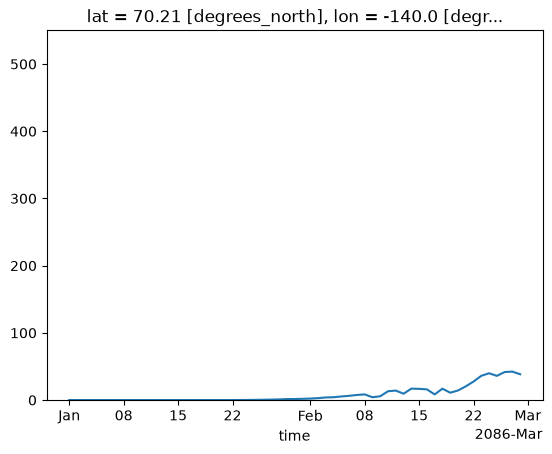

In [22]:
FOCUS_LAT = 70  # -33.98668063995415
FOCUS_LON = -140

scenario_debiased.sel(lat=FOCUS_LAT, lon=FOCUS_LON, method="nearest").sel(
    time=slice("2086-01", "2086-02")
).plot()
plt.ylim(0, 550)

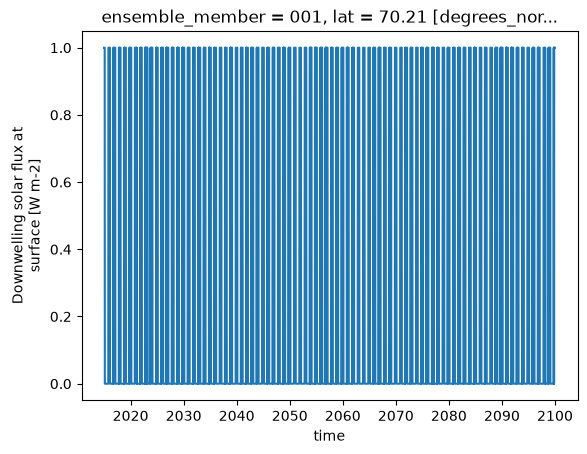

In [23]:
(model_scenario < 10).sel(lat=FOCUS_LAT, lon=FOCUS_LON, method="nearest").plot()

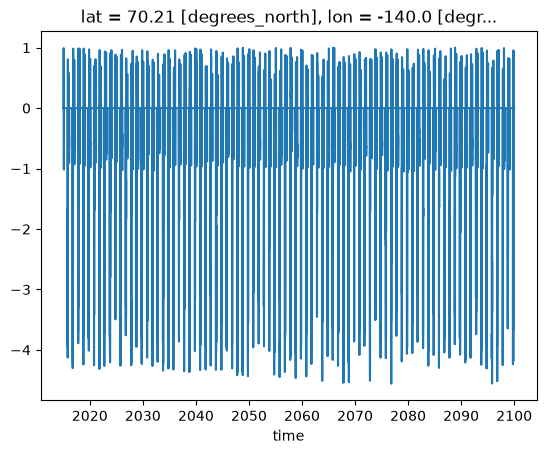

In [24]:
(scenario_debiased - qdm638_scenario).sel(lat=FOCUS_LAT, lon=FOCUS_LON, method="nearest").plot()

In [25]:
(
    (scenario_debiased - qdm638_scenario).sel(lat=FOCUS_LAT, lon=FOCUS_LON, method="nearest")
    < -1e-4
).sum().values

array(3011)

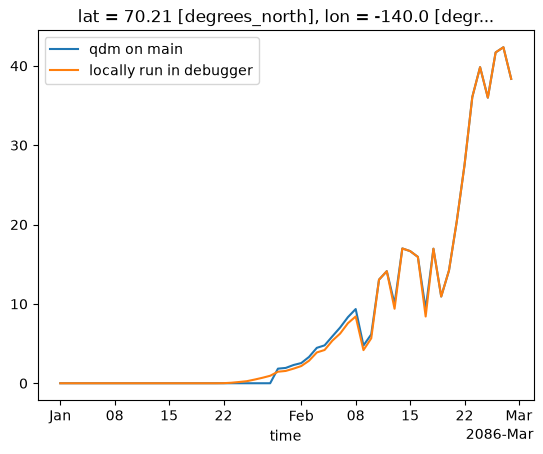

In [27]:
qdm638_scenario.sel(lat=FOCUS_LAT, lon=FOCUS_LON, method="nearest").sel(
    time=slice("2086-01", "2086-02")
).plot(label="qdm on main")
scenario_debiased.sel(lat=FOCUS_LAT, lon=FOCUS_LON, method="nearest").sel(
    time=slice("2086-01", "2086-02")
).plot(label="locally run in debugger")
plt.legend()

lots of places have low rsds values - below 10 w/m2! this change will change a lot of pixels!

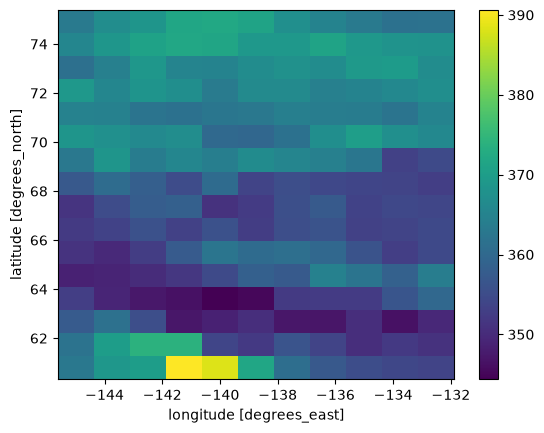

In [32]:
scenario_debiased.max(dim="time").plot()

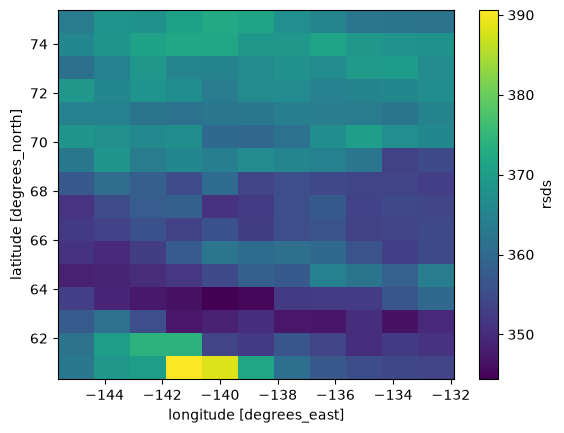

In [29]:
qdm638_scenario.max(dim="time").plot()

### Raw GCM reference

In [33]:
# model_hist_s3 / model_scenario were already loaded during Stage 3
# (pipeline._load_scenario_data()) on the same subset — reuse them instead of
# refetching from source.
raw_debiased_coarse = xr.concat([model_hist_s3, model_scenario], dim="time").sortby("time")

## Maps — climate-change delta (qdm638 & local vs raw)

In [34]:
# Per-variable plotting config — unit conversion, axis units, and the below-threshold
# ("dry"/"dark" day) definition all depend on which variable this run is for. Add an
# entry here to support plotting a new variable.
VARIABLE_PLOT_CONFIGS = {
    "pr": {
        "convert": lambda da: da * 86400,  # kg m-2 s-1 -> mm/day
        "units": "mm/day",
        "long_name": "precip",
        "below_threshold_value": 1.0,  # WMO definition: a day with < 1mm precip counts as "dry"
        "below_threshold_label": "dry days",
        "threshold_units": "mm",
        "mean_abs_lims": (-3, 3),
        "p99_abs_lims": (-100, 100),
        "mean_abs_diff_of_deltas_lims": (-1, 1),
        "p99_abs_diff_of_deltas_lims": (-30, 30),
    },
    "rsds": {
        "convert": lambda da: da,  # already W m-2, no conversion needed
        "units": "W/m2",
        "long_name": "rsds",
        "below_threshold_value": 1.0,  # a day with < 1 W/m2 mean insolation counts as "dark"
        "below_threshold_label": "dark days",
        "threshold_units": "W/m2",
        # Not hand-tuned like pr's yet — falls back to per-panel robust scaling.
        "mean_abs_lims": None,
        "p99_abs_lims": None,
        "mean_abs_diff_of_deltas_lims": None,
        "p99_abs_diff_of_deltas_lims": None,
    },
}

VAR_PLOT = VARIABLE_PLOT_CONFIGS[config.variable]

In [35]:
HISTORICAL_PERIOD = slice("1985", "2014")
FUTURE_PERIOD = slice("2060", "2090")

COMPARISON_APPROACHES = ["local"]
ds_dict = {"qdm638": qdm638_debiased_coarse, "local": local_debiased_coarse}

assert ds_dict["qdm638"]["time"].max().values >= np.datetime64(f"{FUTURE_PERIOD.stop}-12-31"), (
    f"qdm638 data only runs through {ds_dict['qdm638']['time'].max().values} — extend "
    "predict_period_end past 2099 in the global-qdm config and rerun before this cell has "
    "data for 2070-2099."
)

qdm638 = VAR_PLOT["convert"](ds_dict["qdm638"])
approach_das = {
    approach: VAR_PLOT["convert"](ds_dict[approach]) for approach in COMPARISON_APPROACHES
}
raw = VAR_PLOT["convert"](raw_debiased_coarse)

In [36]:
BELOW_THRESHOLD = VAR_PLOT["below_threshold_value"]


def cc_delta(da, metric="mean"):
    """(future - historical) delta, plus the historical stat it was built from."""
    historical_period = slice("1985", "2014")
    future_period = slice("2030", "2059")
    if metric == "mean":
        hist_stat = da.sel(time=historical_period).mean("time")
        fut_stat = da.sel(time=future_period).mean("time")
    elif metric == "99p":
        hist_stat = da.sel(time=historical_period).quantile(0.99, dim="time")
        fut_stat = da.sel(time=future_period).quantile(0.99, dim="time")
    elif metric == "0.999p":
        hist_stat = da.sel(time=historical_period).quantile(0.999, dim="time")
        fut_stat = da.sel(time=future_period).quantile(0.999, dim="time")
    elif metric == "below_threshold":
        hist_stat = (da.sel(time=historical_period) < BELOW_THRESHOLD).mean("time") * 100
        fut_stat = (da.sel(time=future_period) < BELOW_THRESHOLD).mean("time") * 100
    return (fut_stat - hist_stat).compute(), hist_stat.compute()


def relative_delta(absolute_delta, hist_stat):
    return absolute_delta / hist_stat * 100

In [37]:
plot_dict = {"absolute": {}, "relative": {}}
for metric in ["mean", "99p", "below_threshold"]:
    print(metric)

    delta_raw, hist_raw = cc_delta(raw, metric=metric)
    delta_qdm638, hist_qdm638 = cc_delta(qdm638, metric=metric)
    qdm638_minus_raw = delta_qdm638 - delta_raw
    rel_raw = relative_delta(delta_raw, hist_raw)
    rel_qdm638 = relative_delta(delta_qdm638, hist_qdm638)
    rel_qdm638_minus_raw = rel_qdm638 - rel_raw

    abs_panels = {
        "Δ raw": [delta_raw, (0, 0)],
        "Δ qdm638": [delta_qdm638, (0, 1)],
        "Δ qdm638 - Δ raw": [qdm638_minus_raw, (1, 1)],
    }
    rel_panels = {
        "Δ raw": [rel_raw, (0, 0)],
        "Δ qdm638": [rel_qdm638, (0, 1)],
        "Δ qdm638 - Δ raw": [rel_qdm638_minus_raw, (1, 1)],
    }

    for col, approach in enumerate(COMPARISON_APPROACHES, start=2):
        delta_approach, hist_approach = cc_delta(approach_das[approach], metric=metric)
        approach_minus_raw = delta_approach - delta_raw
        abs_panels[f"Δ {approach}"] = [delta_approach, (0, col)]
        abs_panels[f"Δ {approach} - Δ raw"] = [approach_minus_raw, (1, col)]
        abs_panels[f"difference of deltas ({approach} - qdm638)"] = [
            approach_minus_raw - qdm638_minus_raw,
            (2, col),
        ]

        rel_approach = relative_delta(delta_approach, hist_approach)
        rel_approach_minus_raw = rel_approach - rel_raw
        rel_panels[f"Δ {approach}"] = [rel_approach, (0, col)]
        rel_panels[f"Δ {approach} - Δ raw"] = [rel_approach_minus_raw, (1, col)]
        rel_panels[f"difference of deltas ({approach} - qdm638)"] = [
            rel_approach_minus_raw - rel_qdm638_minus_raw,
            (2, col),
        ]

    plot_dict["absolute"][metric] = abs_panels
    plot_dict["relative"][metric] = rel_panels

mean
99p
below_threshold


In [38]:
# Per-metric absolute-panel bounds. mean/99p bounds are unit-dependent (mm/day vs W/m2,
# ...), so they come from VAR_PLOT — a variable without hand-tuned bounds omits the entry
# below (`abs_lims`/`diff_of_deltas_lims` stays None), which leaves those titles out of
# var_lims_dict entirely so `_shared_lims` pools them into one shared robust range instead
# of letting each panel pick its own (see the plotting cell below). below_threshold is
# always a percentage-point change in the % of days below BELOW_THRESHOLD, so its bounds
# stay the same regardless of variable.
_METRIC_ABS_LIMS = {
    "mean": VAR_PLOT["mean_abs_lims"],
    "99p": VAR_PLOT["p99_abs_lims"],
    "below_threshold": (-20, 20),
}
_METRIC_ABS_DIFF_OF_DELTAS_LIMS = {
    "mean": VAR_PLOT["mean_abs_diff_of_deltas_lims"],
    "99p": VAR_PLOT["p99_abs_diff_of_deltas_lims"],
    "below_threshold": (-10, 10),
}
_REL_LIMS = (-5, 5)
_REL_DIFF_OF_DELTAS_LIMS = (-5, 5)

var_lims_dict = {"absolute": {}, "relative": {}}
for metric, abs_lims in _METRIC_ABS_LIMS.items():
    diff_of_deltas_lims = _METRIC_ABS_DIFF_OF_DELTAS_LIMS[metric]
    var_lims_dict["absolute"][metric] = {}
    var_lims_dict["relative"][metric] = {"Δ raw": _REL_LIMS, "Δ qdm638": _REL_LIMS}
    if abs_lims is not None:
        var_lims_dict["absolute"][metric]["Δ raw"] = abs_lims
        var_lims_dict["absolute"][metric]["Δ qdm638"] = abs_lims
        var_lims_dict["absolute"][metric]["Δ qdm638 - Δ raw"] = abs_lims
    for approach in COMPARISON_APPROACHES:
        if abs_lims is not None:
            var_lims_dict["absolute"][metric][f"Δ {approach}"] = abs_lims
            var_lims_dict["absolute"][metric][f"Δ {approach} - Δ raw"] = abs_lims
        if diff_of_deltas_lims is not None:
            var_lims_dict["absolute"][metric][f"difference of deltas ({approach} - qdm638)"] = (
                diff_of_deltas_lims
            )
        var_lims_dict["relative"][metric][f"Δ {approach}"] = _REL_LIMS
        var_lims_dict["relative"][metric][f"difference of deltas ({approach} - qdm638)"] = (
            _REL_DIFF_OF_DELTAS_LIMS
        )

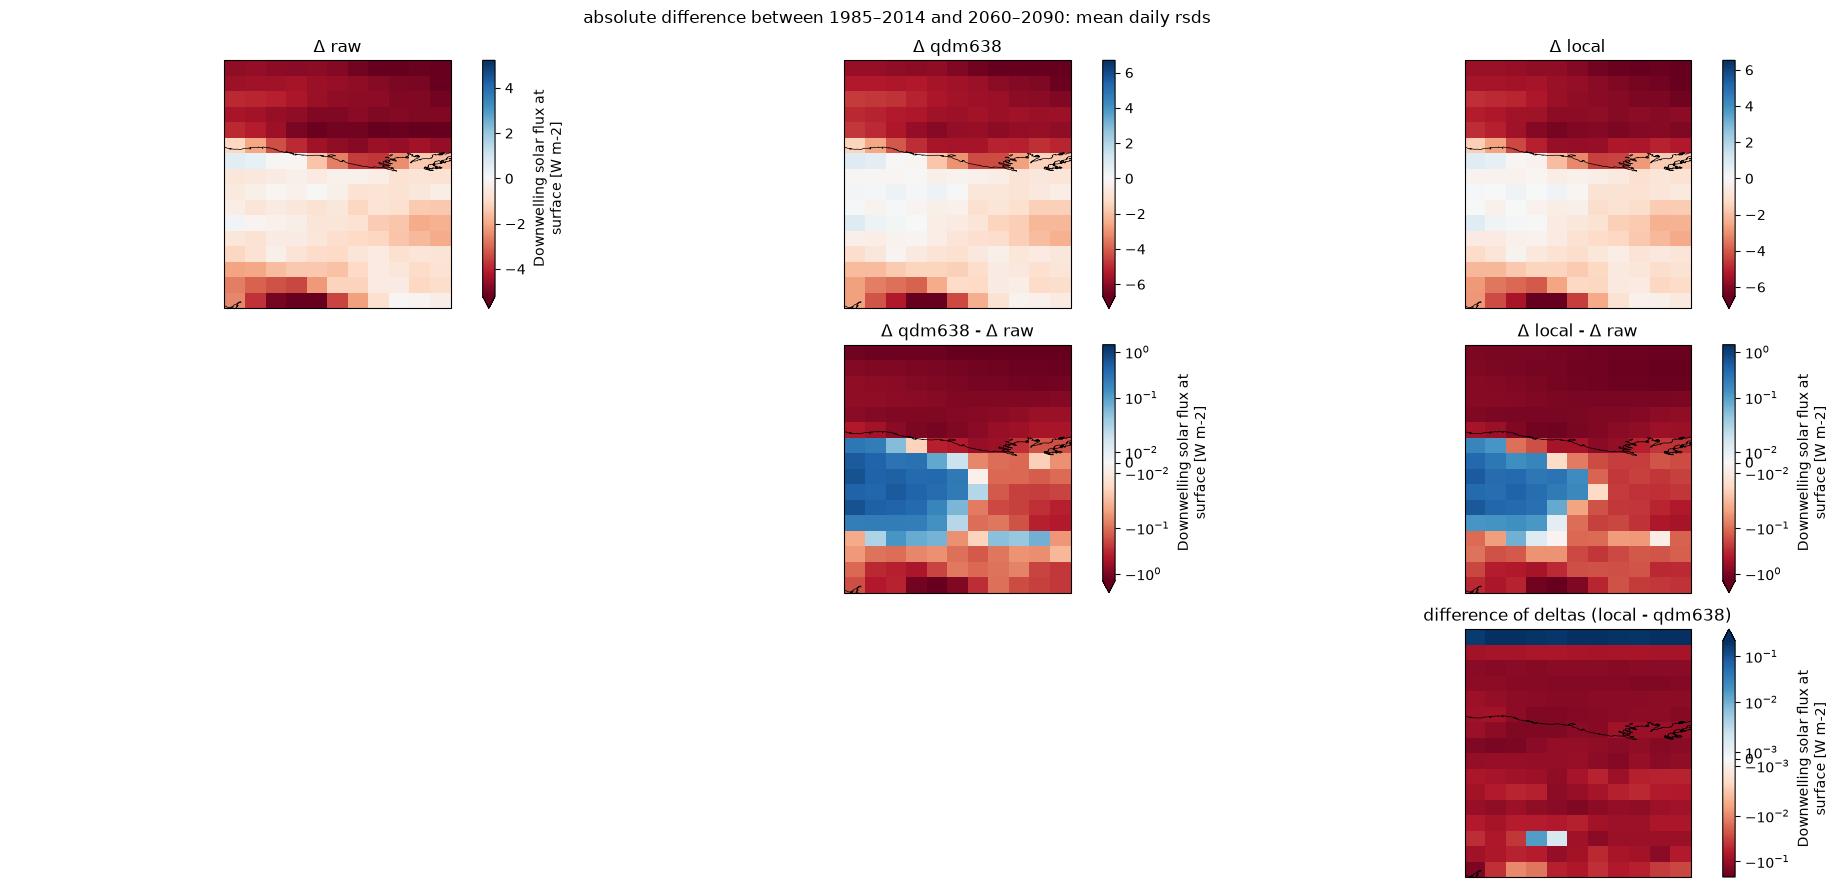

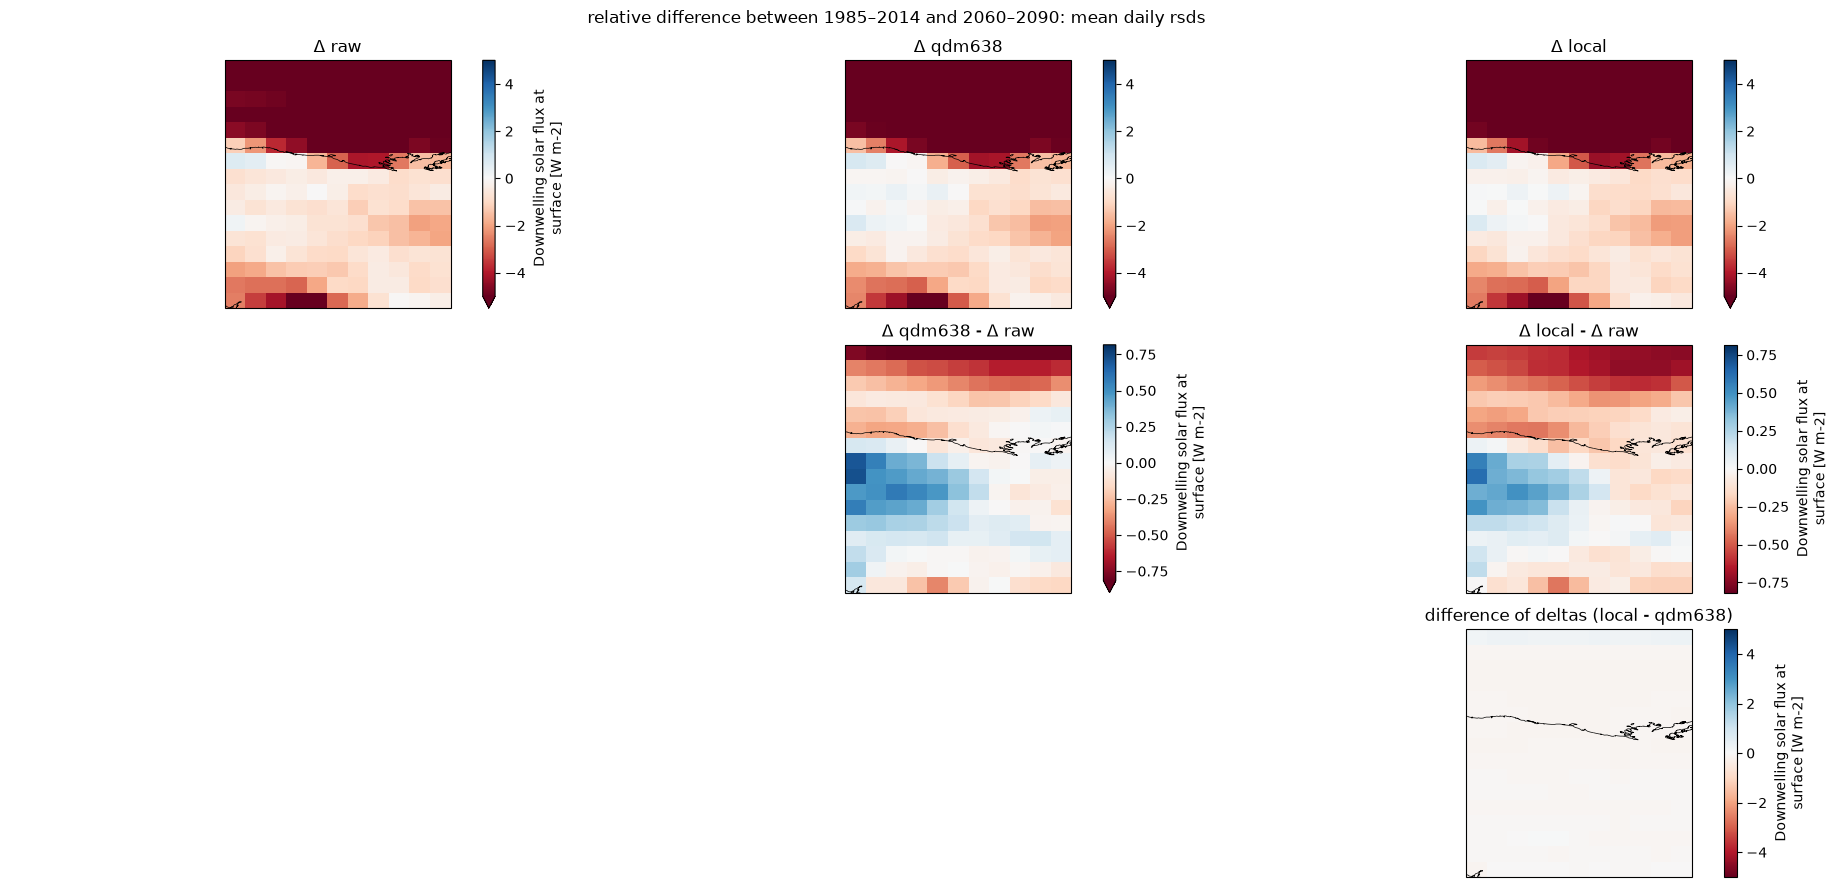

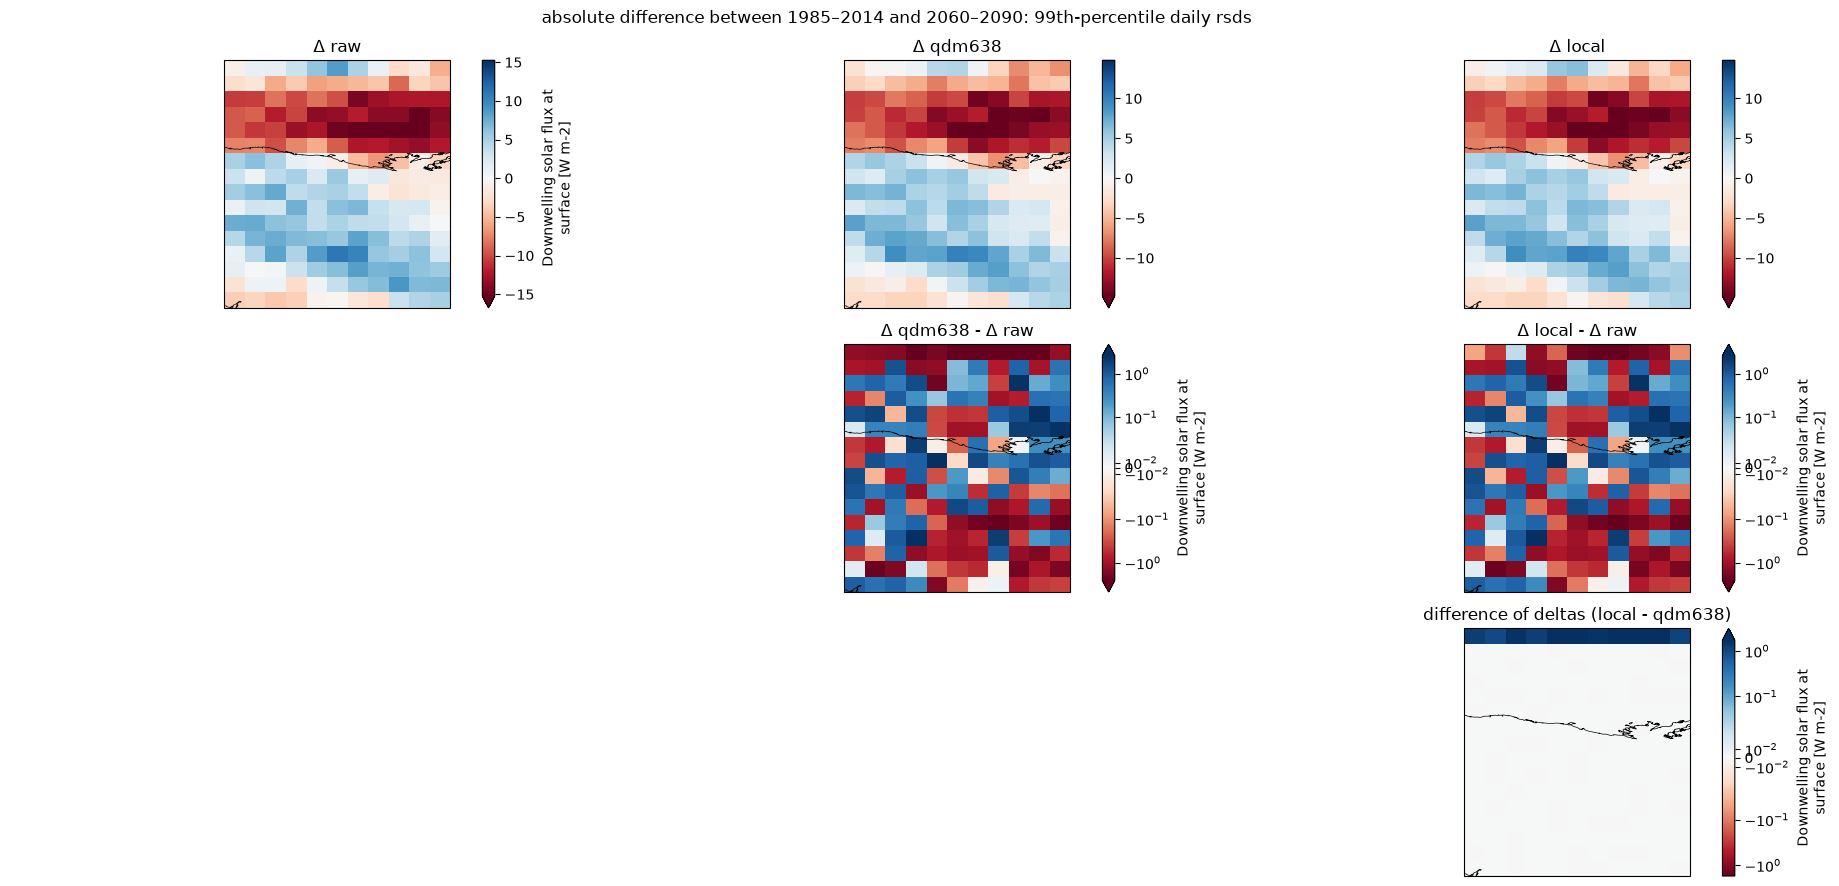

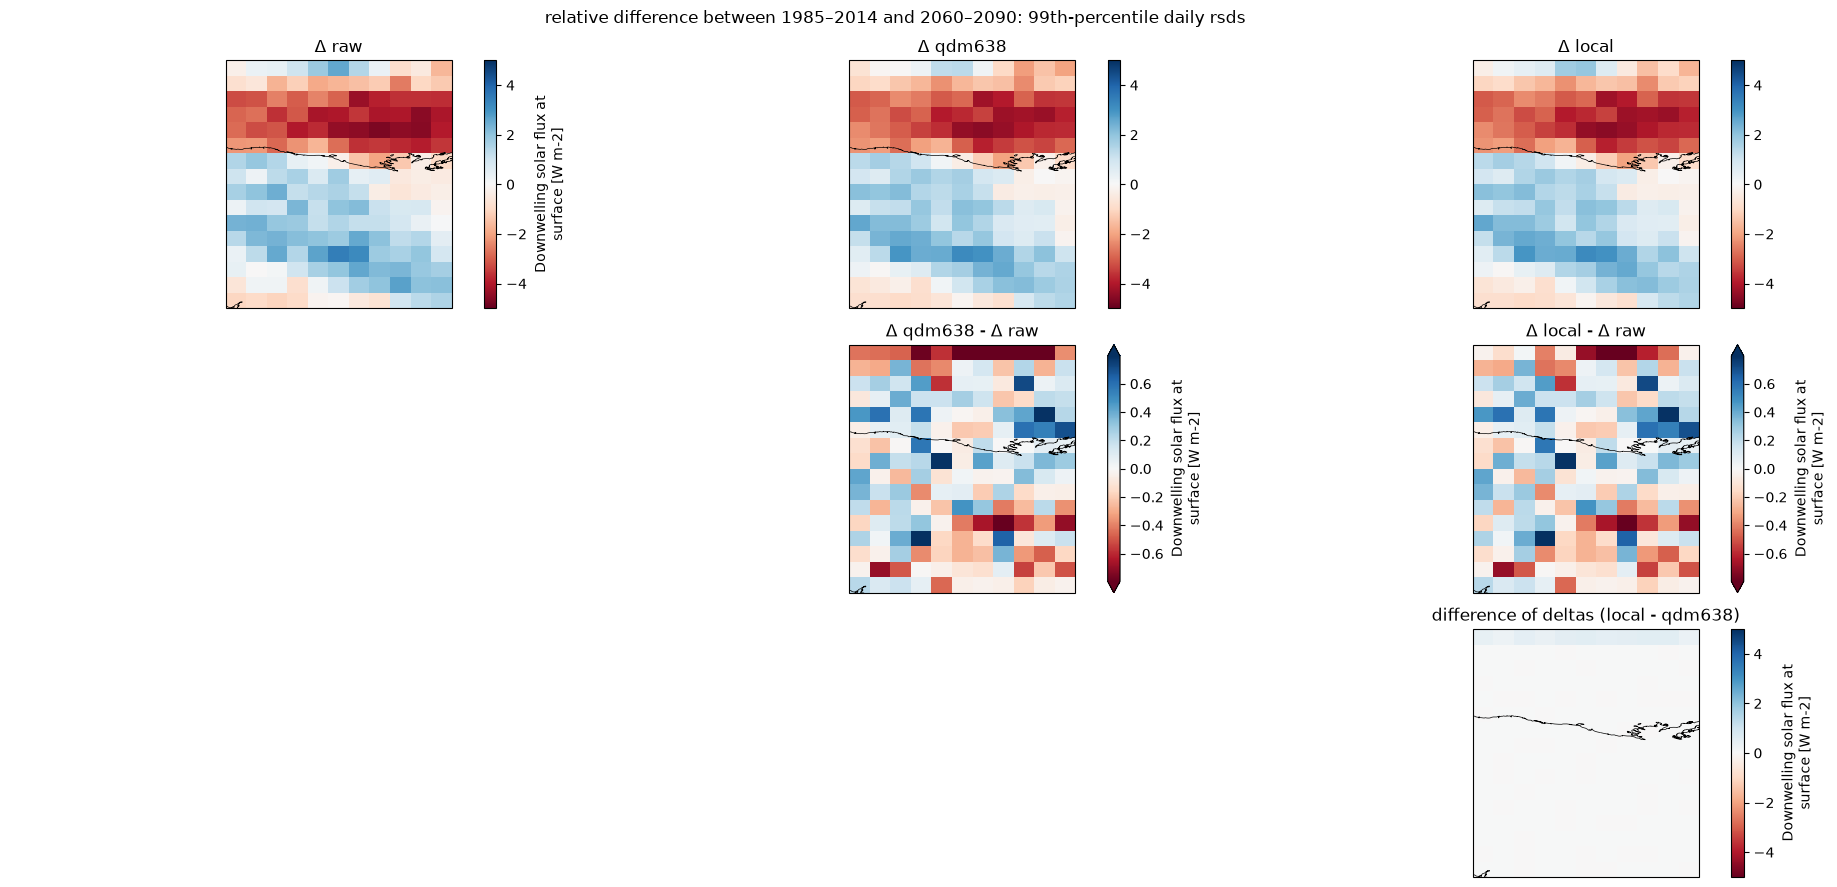

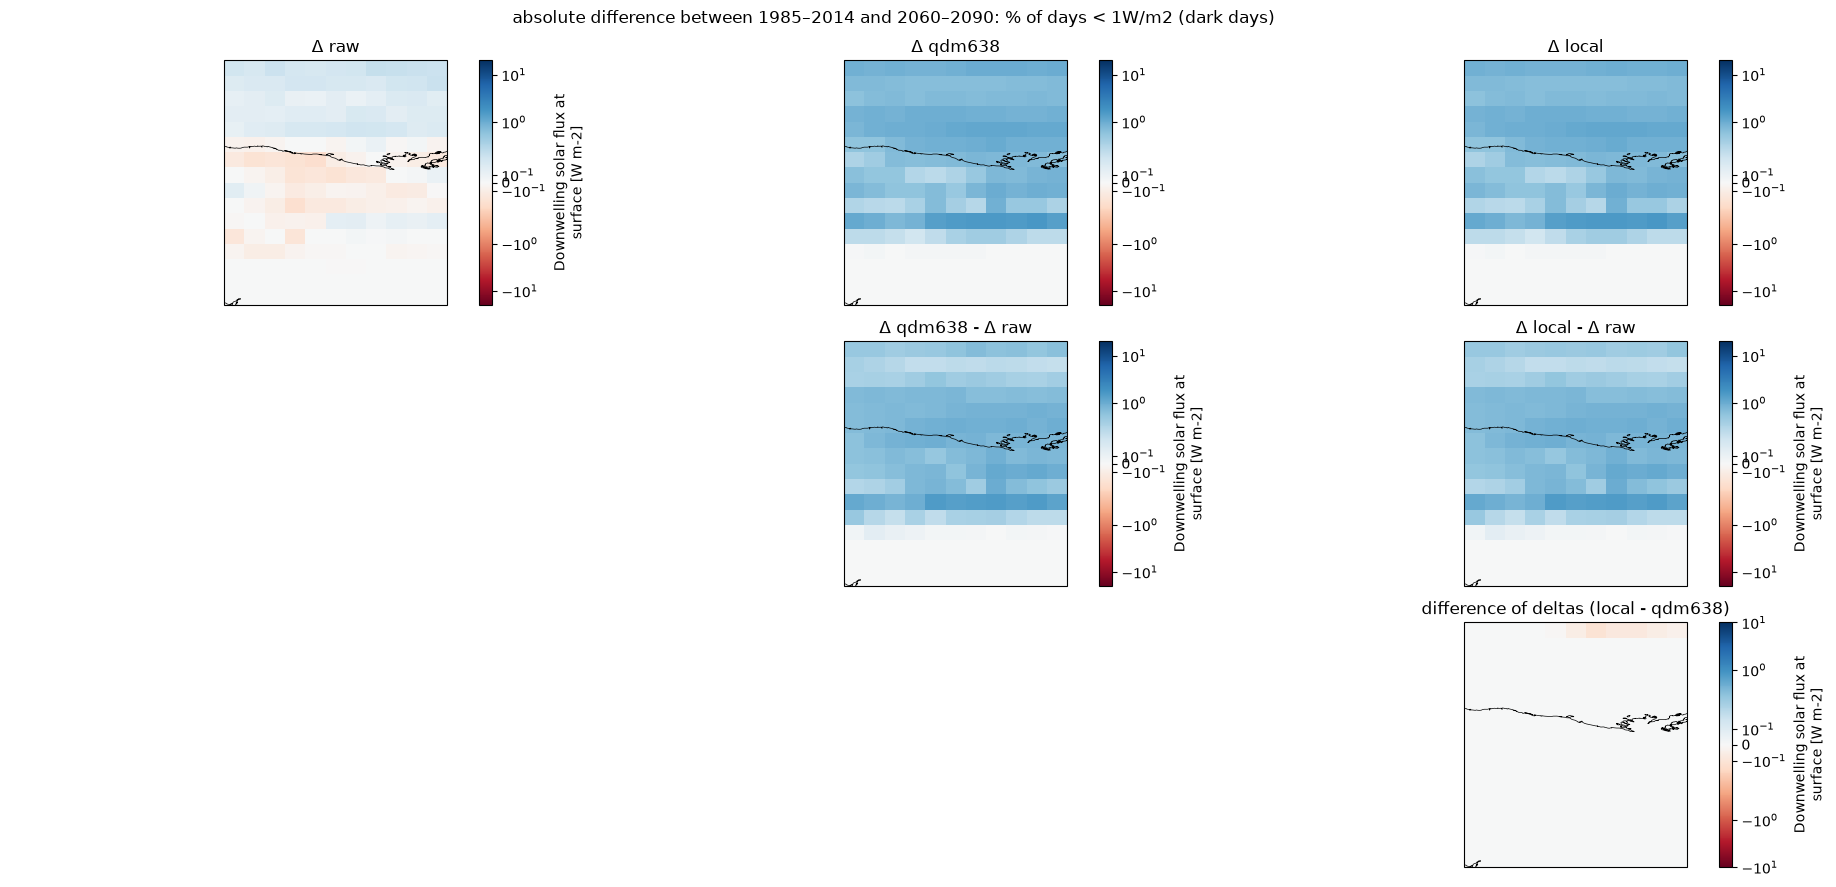

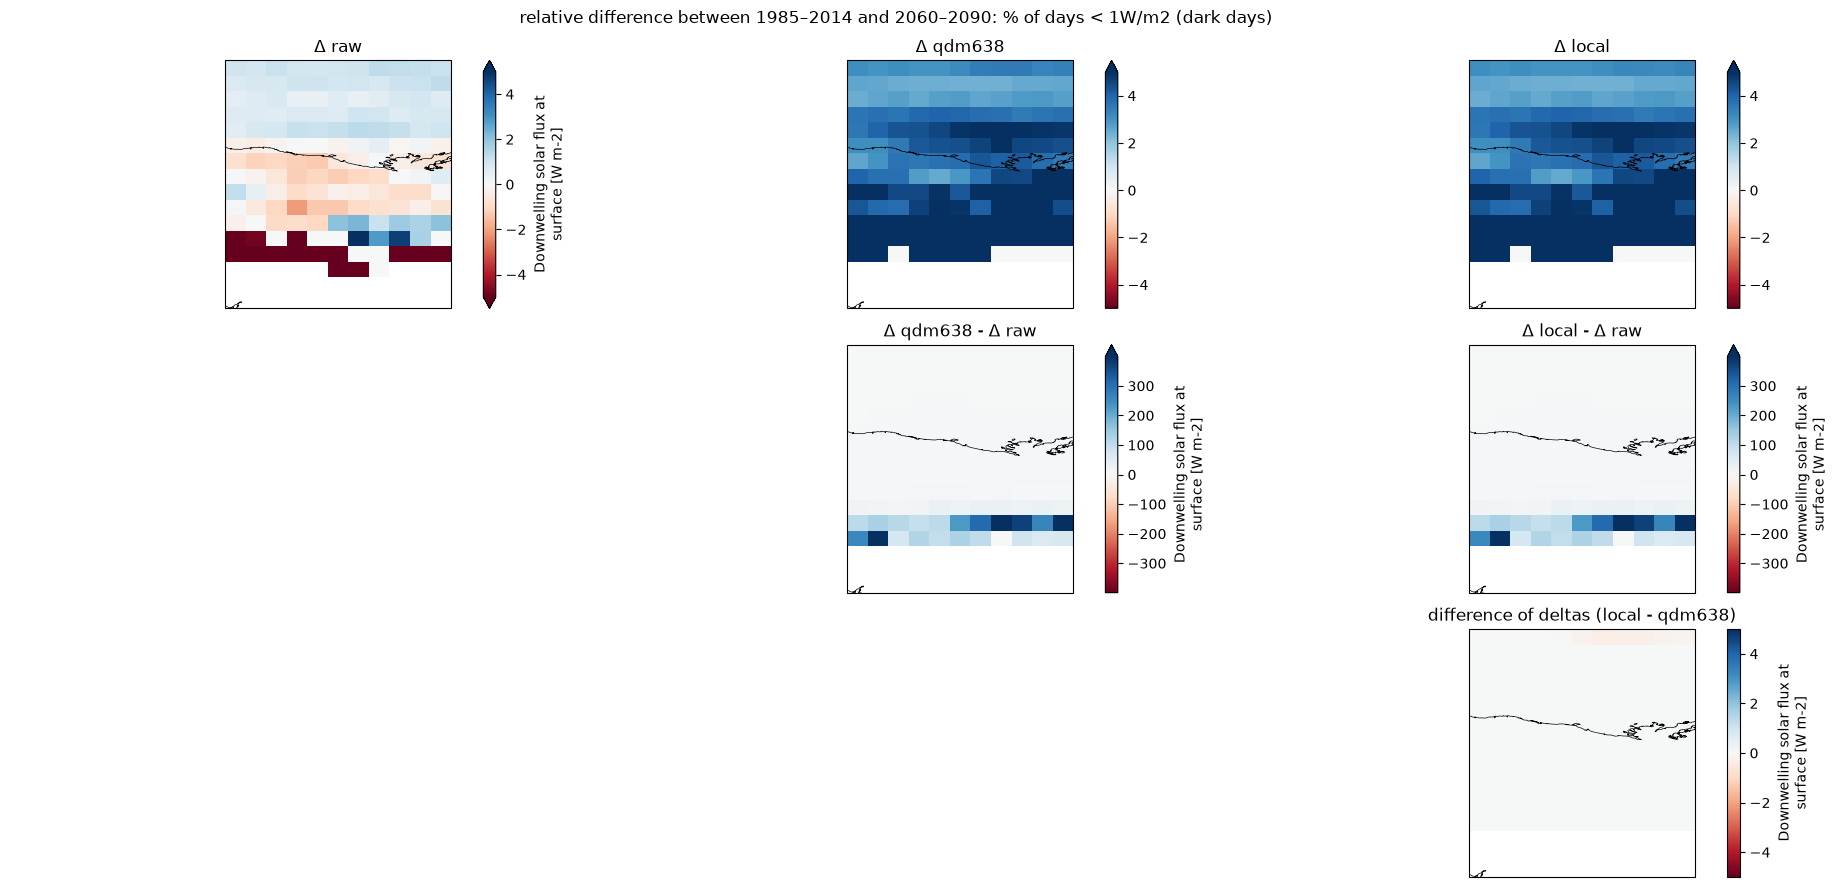

In [39]:
from matplotlib.colors import SymLogNorm

_proj_kw = dict(projection=ccrs.PlateCarree()) if _HAS_CARTOPY else {}
_transform_kw = dict(transform=ccrs.PlateCarree()) if _HAS_CARTOPY else {}

_N_COLS = 2 + len(COMPARISON_APPROACHES)  # raw, qdm638, + one column per approach
_N_ROWS = 3  # row 0: Δ; row 1: Δ − Δ raw; row 2: difference of deltas vs qdm638

_METRIC_LABELS = {
    "mean": f"mean daily {VAR_PLOT['long_name']}",
    "99p": f"99th-percentile daily {VAR_PLOT['long_name']}",
    "below_threshold": f"% of days < {BELOW_THRESHOLD:g}{VAR_PLOT['threshold_units']} ({VAR_PLOT['below_threshold_label']})",
}

_RESIDUAL_TITLES = ("Δ qdm638 - Δ raw",) + tuple(
    f"Δ {approach} - Δ raw" for approach in COMPARISON_APPROACHES
)
_DIFF_OF_DELTAS_TITLES = tuple(
    f"difference of deltas ({approach} - qdm638)" for approach in COMPARISON_APPROACHES
)


def _shared_robust_center0_limits(*das):
    """Symmetric-around-zero robust (2nd/98th percentile) limits pooled across arrays."""
    combined = np.concatenate([np.asarray(da.values).ravel() for da in das])
    combined = combined[np.isfinite(combined)]
    p2, p98 = np.nanpercentile(combined, [2, 98])
    vlim = max(abs(p2), abs(p98))
    return -vlim, vlim


def _shared_lims(method, metric, titles):
    """var_lims_dict values where present; a pooled robust range for the rest."""
    lims = {
        t: var_lims_dict[method][metric][t] for t in titles if t in var_lims_dict[method][metric]
    }
    if len(lims) < len(titles):
        shared_vmin, shared_vmax = _shared_robust_center0_limits(
            *(plot_dict[method][metric][t][0] for t in titles)
        )
        for t in titles:
            lims.setdefault(t, (shared_vmin, shared_vmax))
    return lims


for metric in ["mean", "99p", "below_threshold"]:
    for method in ["absolute", "relative"]:
        fig, axes = plt.subplots(_N_ROWS, _N_COLS, figsize=(6.5 * _N_COLS, 9), subplot_kw=_proj_kw)

        shared_lims = {
            **_shared_lims(method, metric, _RESIDUAL_TITLES),
            **_shared_lims(method, metric, _DIFF_OF_DELTAS_TITLES),
        }

        for title, [da, (i, j)] in plot_dict[method][metric].items():
            lims = (
                shared_lims[title]
                if title in shared_lims
                else var_lims_dict[method][metric].get(title)
            )
            if lims is not None:
                vmin, vmax = lims
                if method == "absolute":
                    norm = SymLogNorm(linthresh=vmax / 30, vmin=vmin, vmax=vmax)
                    da.plot(ax=axes[i, j], norm=norm, cmap="RdBu", **_transform_kw)
                else:
                    da.plot(ax=axes[i, j], vmin=vmin, vmax=vmax, cmap="RdBu", **_transform_kw)
            else:
                da.plot(ax=axes[i, j], robust=True, cmap="RdBu", center=0, **_transform_kw)
            if _HAS_CARTOPY:
                axes[i, j].add_feature(cfeature.COASTLINE, linewidth=0.5)
            axes[i, j].set_title(title)
            axes[i, j].set_xlabel(None)
            axes[i, j].set_ylabel(None)
        # No "raw - raw" residual and no "qdm638 - qdm638" difference of deltas.
        axes[1, 0].set_axis_off()
        axes[2, 0].set_axis_off()
        axes[2, 1].set_axis_off()
        fig.suptitle(
            f"{method} difference between {HISTORICAL_PERIOD.start}–{HISTORICAL_PERIOD.stop} and {FUTURE_PERIOD.start}–{FUTURE_PERIOD.stop}: {_METRIC_LABELS.get(metric, metric)}"
        )
        plt.tight_layout()
        plt.show()